# Домашнее задание по теме «Табличные данные и визуализация»

В этом домашнем задании тебе предстоит работать с данными, включая их загрузку, предварительную обработку, исследовательский анализ и визуализацию. Ты сможешь потренироваться в работе с инструментами анализа данных и сделать выводы на основе датасета.

>### Правила домашнего задания
>1. Нельзя удалять существующие ячейки кода.
>
>2. Можно добавлять и дописывать свои ячейки.
>
>3. Место, куда тебе нужно написать код, помечается комментарием.
>
> 4. Ответ без кода, который подтвердит твоё решение, не засчитывается. Исключение — задачи и вопросы, где код не требуется и нужно сделать вывод из известных данных.
>
 > 5. Код должен быть работоспособным. У проверяющих должна быть возможность воспроизвести все полученные результаты.


## Импорт библиотек

In [572]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from typing import Sequence, List

## Загрузка данных

In [573]:
!gdown 1oHdwGxEV26wuPp1AnC9PacY11FHUiRoU


Downloading...
From: https://drive.google.com/uc?id=1oHdwGxEV26wuPp1AnC9PacY11FHUiRoU
To: /content/pokemon.csv
100% 161k/161k [00:00<00:00, 60.6MB/s]


В задачах ты будешь работать с [The Complete Pokemon Dataset](https://www.kaggle.com/datasets/rounakbanik/pokemon), в котором описаны характеристики покемонов.

In [574]:
df = pd.read_csv('./pokemon.csv')
df


,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,...,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,"['Overgrow', 'Chlorophyll']",1.00,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,1,65,65,45,grass,poison,6.9,1,0
1,"['Overgrow', 'Chlorophyll']",1.00,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,2,80,80,60,grass,poison,13.0,1,0
2,"['Overgrow', 'Chlorophyll']",1.00,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,3,122,120,80,grass,poison,100.0,1,0
3,"['Blaze', 'Solar Power']",0.50,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,4,60,50,65,fire,NaN,8.5,1,0
4,"['Blaze', 'Solar Power']",0.50,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,5,80,65,80,fire,NaN,19.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,['Beast Boost'],0.25,1.0,0.5,2.0,0.5,1.0,2.0,0.5,1.0,...,NaN,797,107,101,61,steel,flying,999.9,7,1
797,['Beast Boost'],1.00,1.0,0.5,0.5,0.5,2.0,4.0,1.0,1.0,...,NaN,798,59,31,109,grass,steel,0.1,7,1
798,['Beast Boost'],2.00,0.5,2.0,0.5,4.0,2.0,0.5,1.0,0.5,...,NaN,799,97,53,43,dark,dragon,888.0,7,1
799,['Prism Armor'],2.00,2.0,1.0,1.0,1.0,0.5,1.0,1.0,2.0,...,NaN,800,127,89,79,psychic,NaN,230.0,7,1


## Задача 1 [1 балл]

1. Выведи информацию о типах данных, хранящихся в каждом столбце датасета. Отдельно сделай комментарий и напиши, какие типы не числовые — это потребуется в последующей предобработке **[0,5 балла]**.
2. NaN — объясни причину их появления в датасете, а также избавься от них (в столбцах `type2` и `weight_kg` запрещается просто вырезать строки с NaN). Кратко укажи в комментарии, какой метод борьбы с NaN выбран и почему **[0,5 балла]**.

In [575]:
df.dtypes


,0
abilities,object
against_bug,float64
against_dark,float64
against_dragon,float64
against_electric,float64
against_fairy,float64
against_fight,float64
against_fire,float64
against_flying,float64
against_ghost,float64


Типы, которые ниже выведены, не числовые

In [576]:
df.select_dtypes(include='object').columns

Index(['abilities', 'capture_rate', 'classfication', 'japanese_name', 'name',
       'type1', 'type2'],
      dtype='object')

In [577]:
df.isna().sum()

,0
abilities,0
against_bug,0
against_dark,0
against_dragon,0
against_electric,0
against_fairy,0
against_fight,0
against_fire,0
against_flying,0
against_ghost,0


Type2 пустой, так как не все покемоны имеют второй тип, это задуманная фича. Вес для удобства мы заполним медианой.

In [578]:
df['type2'] = df['type2'].where(df['type2'].notna(), "None")

In [579]:
df['type2'].unique()

array(['poison', 'None', 'flying', 'dark', 'electric', 'ice', 'ground',
       'fairy', 'grass', 'fighting', 'psychic', 'steel', 'fire', 'rock',
       'water', 'dragon', 'ghost', 'bug', 'normal'], dtype=object)

In [580]:
df['weight_kg'] = df['weight_kg'].fillna(df['weight_kg'].median())

## Задача 2 [1 балл]

Изучи описание признаков датасета и убери из него неинформативные признаки. Обоснуй комментариями рядом с кодом, почему ты считаешь их ненужными.

In [581]:
df.columns[df.isna().any()]

Index(['height_m', 'percentage_male'], dtype='object')

Уберем процент пола, поколение, имя, японское имя, base_total, это сумма хп и тд, номер в покедексе так как эти данные в будущем не используются

In [582]:
df = df.drop(columns=['percentage_male', 'generation', 'name', 'japanese_name', 'base_total', 'pokedex_number'], errors='ignore')

In [583]:
df.columns

Index(['abilities', 'against_bug', 'against_dark', 'against_dragon',
       'against_electric', 'against_fairy', 'against_fight', 'against_fire',
       'against_flying', 'against_ghost', 'against_grass', 'against_ground',
       'against_ice', 'against_normal', 'against_poison', 'against_psychic',
       'against_rock', 'against_steel', 'against_water', 'attack',
       'base_egg_steps', 'base_happiness', 'capture_rate', 'classfication',
       'defense', 'experience_growth', 'height_m', 'hp', 'sp_attack',
       'sp_defense', 'speed', 'type1', 'type2', 'weight_kg', 'is_legendary'],
      dtype='object')

## Задача 3 [1 балл]
1. Построй матрицу корреляции для столбцов `is_legendary`, `hp`, `attack`, `defense`, `speed`.
2. Выдвини и напиши 2–3 гипотезы о взаимосвязи между этими величинами.

<Axes: >

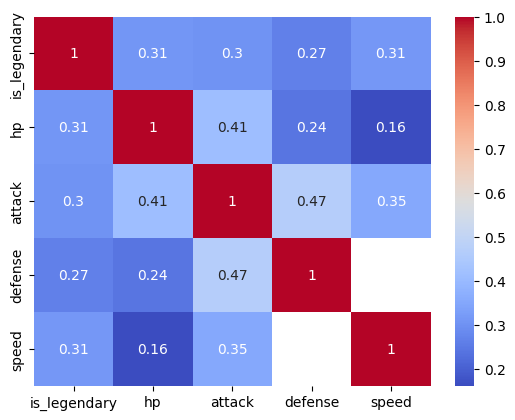

In [584]:
corr = df.loc[:, ['is_legendary', 'hp', 'attack', 'defense', 'speed']].corr()
sns.heatmap(data=corr, cmap='coolwarm', annot=True, mask=np.abs(corr) <= 0.1)

Все параметры коррелируют с тем, легендарный ли покемон, так как это довольно очевидно, что если покемон крутой, то у него и выше характеристики.
А также у покемонов с высоким хп прослеживается, что у них ниже скорость и защита, так как для баланса в играх делают, чтобы он был либо с высоким хп и низким дефом, либо наоборот.

## Задача 4 [1 балл]

Подготовь датасет для применения алгоритма DBSCAN: обработай категориальные столбцы.  

В этом поможет [MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) или [StandartScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).

Совет: не следует ограничиваться банальным One Hot Encoding. Возможно, стоит оставить в признаках с очень большим количеством уникальных значений только самые популярные. Это поможет улучшить качество кластеризации.

>***Примечание:*** если в коде будет использован базовый минимум (OHE и dropna), то задание будет оценено максимум в 0,5 балла. Чтобы претендовать на полный балл, необходимо либо прислушаться к совету, либо придумать что-то самостоятельно и кратко пояснить выбранную стратегию предобработки данных.



hp attack sp_attack sp_defense (sp_ специальная атака или защита поэтому не убрали) defense speed experience_growth имеют нормальное распределение, поэтому мы используем на них standartscaler

на against_* мы используем minmaxscaler, так как пусть они и имеют похожее на нормальное распределение, мы ничего не потеряем, если попробуем использовать именно это


In [585]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [586]:
df.loc[df['capture_rate'] == '30 (Meteorite)255 (Core)', 'capture_rate'] = (30+255)/2

In [587]:
norm = ['hp', 'attack', 'sp_attack', 'sp_defense', 'defense', 'speed', 'experience_growth']
minmax = ['base_egg_steps', 'weight_kg', 'height_m', 'base_egg_steps', 'base_happiness', 'capture_rate']
for i in norm:
  scaler = StandardScaler()
  df[i] = scaler.fit_transform(df[[i]])

for i in df.columns:
  if i.startswith("against_") or i in minmax:
    scaler = MinMaxScaler()
    df[i] = scaler.fit_transform(df[[i]])

In [588]:
with pd.option_context("display.min_rows", 50, "display.max_rows", 100, \
                       "display.max_columns", 1500, 'display.max_colwidth', 150):
    display(df)


,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,against_grass,against_ground,against_ice,against_normal,against_poison,against_psychic,against_rock,against_steel,against_water,attack,base_egg_steps,base_happiness,capture_rate,classfication,defense,experience_growth,height_m,hp,sp_attack,sp_defense,speed,type1,type2,weight_kg,is_legendary
0,"['Overgrow', 'Chlorophyll']",0.200000,0.200000,0.50,0.125,0.066667,0.1250,0.466667,0.466667,0.250,0.000000,0.250,0.466667,1.0,0.2500,0.5000,0.200000,0.200000,0.066667,-0.897909,0.130435,0.5,0.166667,Seed Pokémon,-0.780773,0.030371,0.041667,-0.902083,-0.195025,-0.211687,-0.738486,grass,poison,0.006801,0
1,"['Overgrow', 'Chlorophyll']",0.200000,0.200000,0.50,0.125,0.066667,0.1250,0.466667,0.466667,0.250,0.000000,0.250,0.466667,1.0,0.2500,0.5000,0.200000,0.200000,0.066667,-0.493413,0.130435,0.5,0.166667,Seed Pokémon,-0.325488,0.030371,0.062500,-0.337312,0.268888,0.325465,-0.219268,grass,poison,0.012903,0
2,"['Overgrow', 'Chlorophyll']",0.200000,0.200000,0.50,0.125,0.066667,0.1250,0.466667,0.466667,0.250,0.000000,0.250,0.466667,1.0,0.2500,0.5000,0.200000,0.200000,0.066667,0.688960,0.130435,0.5,0.166667,Seed Pokémon,1.625735,0.030371,0.131944,0.415717,1.567846,1.757871,0.473022,grass,poison,0.099920,0
3,"['Blaze', 'Solar Power']",0.066667,0.200000,0.50,0.250,0.066667,0.2500,0.066667,0.200000,0.250,0.066667,0.500,0.066667,1.0,0.2500,0.2500,0.466667,0.066667,0.466667,-0.804564,0.130435,0.5,0.166667,Lizard Pokémon,-0.975896,0.030371,0.034722,-1.127992,-0.349663,-0.748839,-0.046196,fire,None,0.008402,0
4,"['Blaze', 'Solar Power']",0.066667,0.200000,0.50,0.250,0.066667,0.2500,0.066667,0.200000,0.250,0.066667,0.500,0.066667,1.0,0.2500,0.2500,0.466667,0.066667,0.466667,-0.431183,0.130435,0.5,0.166667,Flame Pokémon,-0.488090,0.030371,0.069444,-0.412614,0.268888,-0.211687,0.473022,fire,None,0.018904,0
5,"['Blaze', 'Solar Power']",0.000000,0.200000,0.50,0.500,0.066667,0.1250,0.066667,0.200000,0.250,0.000000,0.000,0.200000,1.0,0.2500,0.2500,1.000000,0.066667,0.466667,0.813421,0.130435,0.5,0.166667,Flame Pokémon,0.162318,0.030371,0.111111,0.340414,2.712165,1.578820,1.165312,fire,flying,0.090418,0
6,"['Torrent', 'Rain Dish']",0.200000,0.200000,0.50,0.500,0.200000,0.2500,0.066667,0.200000,0.250,0.466667,0.250,0.066667,1.0,0.2500,0.2500,0.200000,0.066667,0.066667,-0.929025,0.130435,0.5,0.166667,Tiny Turtle Pokémon,-0.260447,0.030371,0.027778,-0.939734,-0.658938,-0.247497,-0.807715,water,None,0.008902,0
7,"['Torrent', 'Rain Dish']",0.200000,0.200000,0.50,0.500,0.200000,0.2500,0.066667,0.200000,0.250,0.466667,0.250,0.066667,1.0,0.2500,0.2500,0.200000,0.066667,0.066667,-0.462298,0.130435,0.5,0.166667,Turtle Pokémon,0.227358,0.030371,0.062500,-0.374963,-0.195025,0.325465,-0.288498,water,None,0.022404,0
8,"['Torrent', 'Rain Dish']",0.200000,0.200000,0.50,0.500,0.200000,0.2500,0.066667,0.200000,0.250,0.466667,0.250,0.066667,1.0,0.2500,0.2500,0.200000,0.066667,0.066667,0.782306,0.130435,0.5,0.166667,Shellfish Pokémon,1.528174,0.030371,0.104167,0.378065,1.969904,1.578820,0.403793,water,None,0.085417,0
9,"['Shield Dust', 'Run Away']",0.200000,0.200000,0.50,0.250,0.200000,0.1250,0.466667,0.466667,0.250,0.066667,0.125,0.200000,1.0,0.2500,0.2500,0.466667,0.200000,0.200000,-1.489096,0.086957,0.5,1.000000,Worm Pokémon,-1.236059,-0.343390,0.013889,-0.902083,-1.586765,-1.823143,-0.738486,bug,None,0.002801,0


Все числовое нормализовано

Воспользуемся OneHotEncoder для types, уберем classification из-за большого колва классов и abilities

In [589]:
df = df.drop(columns=['classfication', 'abilities'])

In [590]:

t1 = pd.get_dummies(df.loc[:, ['type1']])
t2 = pd.get_dummies(df.loc[:, ['type2']])

t1.columns = [c.replace('type1_', '') for c in t1.columns]
t2.columns = [c.replace('type2_', '') for c in t2.columns]

t = t1|t2
t = t.drop(columns=['None'])
df = df.drop(columns=['type1', 'type2'])



In [591]:
display(df)
display(t)

,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,against_grass,...,capture_rate,defense,experience_growth,height_m,hp,sp_attack,sp_defense,speed,weight_kg,is_legendary
0,0.200000,0.200000,0.50,0.125,0.066667,0.125,0.466667,0.466667,0.250,0.000000,...,0.166667,-0.780773,0.030371,0.041667,-0.902083,-0.195025,-0.211687,-0.738486,0.006801,0
1,0.200000,0.200000,0.50,0.125,0.066667,0.125,0.466667,0.466667,0.250,0.000000,...,0.166667,-0.325488,0.030371,0.062500,-0.337312,0.268888,0.325465,-0.219268,0.012903,0
2,0.200000,0.200000,0.50,0.125,0.066667,0.125,0.466667,0.466667,0.250,0.000000,...,0.166667,1.625735,0.030371,0.131944,0.415717,1.567846,1.757871,0.473022,0.099920,0
3,0.066667,0.200000,0.50,0.250,0.066667,0.250,0.066667,0.200000,0.250,0.066667,...,0.166667,-0.975896,0.030371,0.034722,-1.127992,-0.349663,-0.748839,-0.046196,0.008402,0
4,0.066667,0.200000,0.50,0.250,0.066667,0.250,0.066667,0.200000,0.250,0.066667,...,0.166667,-0.488090,0.030371,0.069444,-0.412614,0.268888,-0.211687,0.473022,0.018904,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,0.000000,0.200000,0.25,0.500,0.066667,0.250,0.466667,0.066667,0.250,0.000000,...,0.087302,0.975327,1.217590,0.631944,1.055791,1.103932,1.077478,-0.184654,1.000000,1
797,0.200000,0.200000,0.25,0.125,0.066667,0.500,1.000000,0.200000,0.250,0.000000,...,1.000000,1.885898,1.217590,0.013889,-0.374963,-0.380590,-1.429231,1.476843,0.000000,1
798,0.466667,0.066667,1.00,0.125,1.000000,0.500,0.066667,0.200000,0.125,0.066667,...,0.047619,-0.650692,1.217590,0.375000,5.799871,0.794657,-0.641408,-0.807715,0.888078,1
799,0.466667,0.466667,0.50,0.250,0.200000,0.125,0.200000,0.200000,0.500,0.200000,...,0.000000,0.910286,1.217590,0.159722,1.055791,1.722483,0.647757,0.438407,0.229946,1


,bug,dark,dragon,electric,fairy,fighting,fire,flying,ghost,grass,ground,ice,normal,poison,psychic,rock,steel,water
0,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False
2,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False
3,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False
797,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False
798,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
799,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False


In [592]:
pd.concat([df, t], axis=1)

,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,against_grass,...,ghost,grass,ground,ice,normal,poison,psychic,rock,steel,water
0,0.200000,0.200000,0.50,0.125,0.066667,0.125,0.466667,0.466667,0.250,0.000000,...,False,True,False,False,False,True,False,False,False,False
1,0.200000,0.200000,0.50,0.125,0.066667,0.125,0.466667,0.466667,0.250,0.000000,...,False,True,False,False,False,True,False,False,False,False
2,0.200000,0.200000,0.50,0.125,0.066667,0.125,0.466667,0.466667,0.250,0.000000,...,False,True,False,False,False,True,False,False,False,False
3,0.066667,0.200000,0.50,0.250,0.066667,0.250,0.066667,0.200000,0.250,0.066667,...,False,False,False,False,False,False,False,False,False,False
4,0.066667,0.200000,0.50,0.250,0.066667,0.250,0.066667,0.200000,0.250,0.066667,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,0.000000,0.200000,0.25,0.500,0.066667,0.250,0.466667,0.066667,0.250,0.000000,...,False,False,False,False,False,False,False,False,True,False
797,0.200000,0.200000,0.25,0.125,0.066667,0.500,1.000000,0.200000,0.250,0.000000,...,False,True,False,False,False,False,False,False,True,False
798,0.466667,0.066667,1.00,0.125,1.000000,0.500,0.066667,0.200000,0.125,0.066667,...,False,False,False,False,False,False,False,False,False,False
799,0.466667,0.466667,0.50,0.250,0.200000,0.125,0.200000,0.200000,0.500,0.200000,...,False,False,False,False,False,False,True,False,False,False


In [593]:
len(df)

801

In [594]:
df.select_dtypes(include='object')

""
0
1
2
3
4
...
796
797
798
799


## Задача 5 [5 баллов]

Теперь по этапам ниже реализуй метод K-means. Предварительно убедись ещё раз, что в датасете остались только числовые признаки.


## Задача 5.1 [1 балл]
Реализуй функцию, которая вычисляет расстояние между двумя точками в N-мерном пространстве.

In [595]:
def euclidean_distance(x1: List[float], x2: List[float]):
    x1 = np.array(x1)
    x2 = np.array(x2)
    """Вычисляет евклидово расстояние между двумя точками."""
    # Напиши код здесь
    return np.sqrt(((x1 - x2) * (x1 - x2)).sum())

In [596]:
# На этих тестах ты можешь проверить работу своей функции

x1 = [0, 0]
x2 = [3, 4]
distance = euclidean_distance(x1, x2)
assert abs(distance - 5.0) < 1e-10, f"Ожидалось 5.0, получено {distance}"

x1 = [0, 0, 1, 0, 1, 2, 0]
x2 = [3, 4, 0, 1, 0, 0, 2]
distance = euclidean_distance(x1, x2)
assert abs(distance - 6.0) < 1e-10, f"Ожидалось 6.0, получено {distance}"

## Задача 5.2 [1 балл]
Напиши функцию, возвращающую k случайных точек из нашей выборки в качестве массива.

Возможно, тебе поможет [np.random.choice](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html).

In [597]:
def initialize_centroids(X, k):

    # Напиши код здесь

    a = np.sort(np.random.choice(len(X), size=k, replace=False))
    return X[a]# Двумерный массив

In [598]:
# На этом тесте ты можешь проверить работу своей функции

X = np.array([
    [0., 0.],
    [1., 1.],
    [2., 2.],
    [3., 3.],
])
k = 2
C = initialize_centroids(X, k)

assert C.shape == (k, X.shape[1]), "Должно вернуть k центроидов той же размерности, что и признаки X"
assert np.all([any(np.array_equal(c, x) for x in X) for c in C]), "Каждый центроид должен быть одной из точек X"

## Задача 5.3 [1 балл]

Напиши функцию, которая назначает класс каждой точке в выборке. У функции есть свойства:
- принимает выборку и список точек-центроидов;
- возвращает массив меток (какой центроид ближе всего к точке).

In [599]:
def assign_clusters(X, centroids):
    """
    Назначает каждой точке ближайший центроид.
    :X: матрица данных (n_samples, n_features)
    :centroids: текущие центроиды (k, n_features)
    :return: массив меток (индексов центроидов)
    """
    labels = np.zeros(X.shape[0], dtype=int)

    for i in range(len(X)):
      v = 0
      minn = 99999999
      for j in range(len(centroids)):
        dist = euclidean_distance(X[i][1], centroids[j][1])
        if dist < minn:
          minn = dist
          v = j
      labels[i] = v

    return labels

In [600]:
# На этом тесте ты можешь проверить работу своей функции

X = np.array([
    [0., 0.],   # Ближе к [0,0]
    [1., 1.],   # Ближе к [0,0]
    [4., 4.],   # Ближе к [5,5]
    [5., 5.],   # Ближе к [5,5]
])

centroids = np.array([
    [0., 0.],
    [5., 5.],
])

labels = assign_clusters(X, centroids)

expected = np.array([0, 0, 1, 1])

assert np.array_equal(labels, expected), f"Ожидали {expected}, получили {labels}"


## Задача 5.4 [1 балл]
Напиши функцию, которая пересчитывает центроиды как среднее точек в каждом кластере.

Функция должна вернуть массив с новыми центроидами.

In [601]:
def update_centroids(X, labels, k, old_centroids):
    """
    Пересчитывает центроиды как среднее точек в каждом кластере.
    :param X: матрица данных
    :param labels: метки кластеров
    :param k: число кластеров
    :param old_centroids: предыдущие центроиды (для пустых кластеров)
    :return: массив с новыми центроидами
    """
    new_centroids = np.zeros((k, X.shape[1]))
    cnt = np.zeros((k))



    for i in range(len(X)):
      new_centroids[labels[i]] += X[i]
      cnt[labels[i]] += 1


    for i in range(k):
      if cnt[i] == 0:
        new_centroids[i] = old_centroids[i]
      else:
        new_centroids[i] /= cnt[i]

    return new_centroids

In [602]:
# На этом тесте ты можешь проверить работу своей функции

X = np.array([
    [0., 0.],
    [2., 0.],
    [0., 2.],
])

# Метки: кластер 0 содержит две точки, кластер 1 содержит одну, кластер 2 пустой
labels = np.array([0, 0, 1])
k = 3

old_centroids = np.array([
    [100., 100.],   # Кластер 0 не пустой
    [200., 200.],   # Кластер 1 не пустой
    [9.,  9.],      # Кластер 2 пустой (нет ни одной точки, которая к нему отнесена)-> должен сохраниться
])

new_centroids = update_centroids(X, labels, k, old_centroids)

expected = np.array([
    [1., 0.],   # Среднее ([0,0] и [2,0])
    [0., 2.],   # Среднее ([0,2])
    [9., 9.],   # Пустой кластер -> старый центроид
])

assert np.allclose(new_centroids, expected), f"Ожидали {expected}, получили {new_centroids}"


## Задача 5.5 [1 балл]
Наконец, напиши функцию, которая собирает воедино всё то, что тебе удалось написать выше, и реализует сам алгоритм K-Means.

In [603]:
def kmeans_fit(X, k, max_iters=100, tol=1e-4):
    """
    Обучает модель K‑Means на данных X.
    :param X: матрица данных (n_samples, n_features)
    :param k: число кластеров
    :param max_iters: макс. число итераций
    :param tol: порог остановки
    :return: centroids, labels
    """

    # Инициализируй центроиды
    centroids = initialize_centroids(X, k)
    labels = assign_clusters(X, centroids)

    for iteration in range(max_iters):
        new_centroids = update_centroids(X, labels, k, centroids)

        # Напиши код здесь # Назначь точки кластерам (labels)
        # Пересчитай центроиды (new_centroids)

        if np.abs(new_centroids-centroids).sum() < tol:
          break
        labels = assign_clusters(X, new_centroids)
        centroids = new_centroids
        # Проверь сходимость и при необходимости остановись
        # pass

    # Если цикл завершился без вычисления labels, посчитай их здесь

    return centroids, labels


## Задача 6 [1 балл]

1. Напиши функцию, которая предсказывает метки кластеров для новых данных.

2. Примени данный самописный метод K-means predit к своему датасету.


In [604]:
def kmeans_predict(X_new, centroids_trained):
    """
    Предсказывает метки кластеров
    :param X_new: матрица новых данных
    :param centroids_trained: обученные центроиды
    :return: метки кластеров
    """
    labels = np.zeros(X_new.shape[0], dtype=int)

    for i in range(len(X_new)):
      v = 0
      minn = 99999999
      for j in range(len(centroids)):
        dist = euclidean_distance(X_new[i][1], centroids_trained[j][1])
        if dist < minn:
          minn = dist
          v = j
      labels[i] = v

    return labels

In [605]:
centroids, labels = kmeans_fit(df.to_numpy(), 5)

## Задача 7 [2 бонусных балла]

1. Примени свой написанный метод к набору точек на плоскости.
2. Примени DBSCAN, написанный на семинаре.
3. Сравни результаты кластеризаций двух методов и прокомментируй отдельно.

In [606]:
points = [
    [1.43, 0.05],
    [1.19, 0.7],
    [0.68, 1.22],
    [0.0, 1.38],
    [-0.73, 1.21],
    [-1.19, 0.68],
    [-1.42, -0.0],
    [-1.19, -0.75],
    [-0.63, -1.18],
    [0.06, -1.36],
    [0.71, -1.18],
    [1.27, -0.66],
    [6.42, 0.92],
    [6.1, 2.22],
    [5.62, 3.42],
    [4.8, 4.43],
    [3.82, 5.27],
    [2.66, 5.91],
    [1.29, 6.29],
    [-0.06, 6.44],
    [-1.37, 6.29],
    [-2.61, 5.88],
    [-3.83, 5.31],
    [-4.78, 4.37],
    [-5.63, 3.47],
    [-6.1, 2.14],
    [-6.42, 0.93],
    [-6.51, -0.08],
    [-6.41, -1.38],
    [-6.02, -2.62],
    [-5.41, -3.76],
    [-4.71, -4.56],
    [-3.7, -5.33],
    [-2.64, -5.97],
    [-1.31, -6.29],
    [0.16, -6.43],
    [1.42, -6.33],
    [2.64, -5.86],
    [3.86, -5.27],
    [4.77, -4.4],
    [5.55, -3.44],
    [6.09, -2.23],
    [6.41, -0.95],
    [6.56, 0.04],
    [8.5, 0.2],
]

In [607]:
X = np.array(points)
centroids, labels = kmeans_fit(X, 2)

In [608]:
from sklearn.cluster import DBSCAN
clustering = DBSCAN(eps=3, min_samples=5).fit(X)
clustering.labels_


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1])

Text(0.5, 1.0, 'K-means')

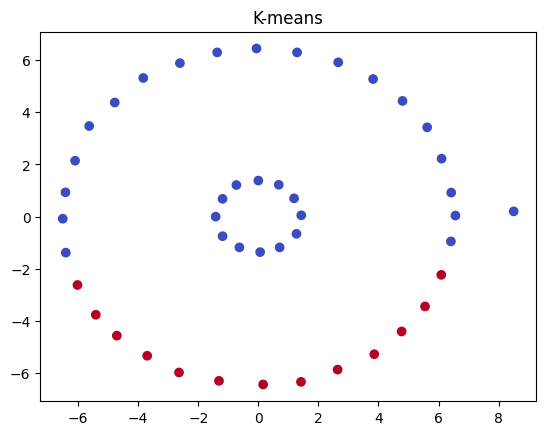

In [609]:
X = np.array(points)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='coolwarm')
plt.title("K-means")


Text(0.5, 1.0, 'DBSCAN')

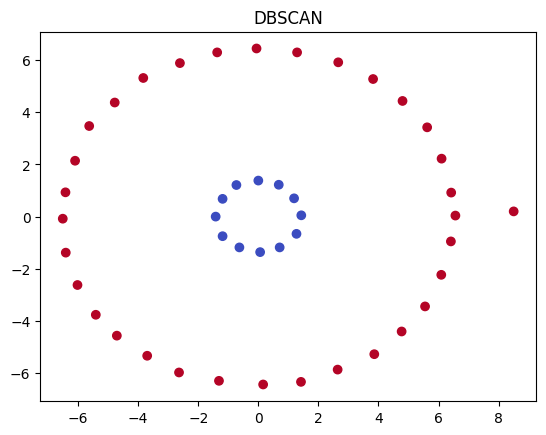

In [610]:
plt.scatter(X[:, 0], X[:, 1], c=clustering.labels_, cmap='coolwarm')
plt.title("DBSCAN")

Здесь видно специфику каждого алгоритма, DBSCAN подбирает точки рядом, за счет чего образуется 2 кластера как внешний и внутренний круг, а K-means просто разделяет надвое, так как разделяет пространство, а не точки